In [ ]:
# !pwd - checking the working directory

In [ ]:
# !pip install --upgrade scikit-learn

In [ ]:
from scipy import stats
import pandas as pd
import numpy as np

# Read data set
hd_df = pd.read_csv('heart disease.csv')

## Show Dataset attributes and descriptive stats

In [ ]:
# Dataset makeup
print("Dataset")
print(hd_df.head())
print("\nDataset information")
print(hd_df.info())

# Descriptive statistics
print("\nDescriptive Statistics")
print(hd_df.describe())

# Duplicates?
print("\nDuplicate rows:\n", hd_df[hd_df.duplicated()])

Dataset
   Age Sex ChestPainType  RestingBP  Cholesterol  FastingBS RestingECG  MaxHR  \
0   40   M           ATA        140          289          0     Normal    172   
1   49   F           NAP        160          180          0     Normal    156   
2   37   M           ATA        130          283          0         ST     98   
3   48   F           ASY        138          214          0     Normal    108   
4   54   M           NAP        150          195          0     Normal    122   

  ExerciseAngina  Oldpeak ST_Slope  HeartDisease  
0              N      0.0       Up             0  
1              N      1.0     Flat             1  
2              N      0.0       Up             0  
3              Y      1.5     Flat             1  
4              N      0.0       Up             0  

Dataset information
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 918 entries, 0 to 917
Data columns (total 12 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          -------

In [ ]:
count_zeros_col = (hd_df['RestingBP'] == 0).sum()
print(f"Number of zeros in RestingBP: {count_zeros_col}")

count_zeros_col = (hd_df['Age'] == 0).sum()
print(f"Number of zeros in Age: {count_zeros_col}")

count_zeros_col = (hd_df['Cholesterol'] == 0).sum()
print(f"Number of zeros in Cholesterol: {count_zeros_col}")

Number of zeros in RestingBP: 1
Number of zeros in Age: 0
Number of zeros in Cholesterol: 172


## Drop rows where certain column values are 0.
### Rows will be fewer than 1% of data set.

In [ ]:
# Drop records with RestingBP = 0
hd_df = hd_df[hd_df['RestingBP'] != 0]

# Re-index after dropped rows
hd_df = hd_df.reset_index(drop=True)

## Show unique values of categorical columns for creating dummy variables

In [ ]:
# Determine unique values in categorical columns
cat_columns = ['Sex', 'ChestPainType', 'RestingECG', 'ExerciseAngina', 'ST_Slope', 'FastingBS']

unique_values = {col: hd_df[col].unique().tolist() for col in cat_columns}

for col, values in unique_values.items():
    print(f"Unique values in '{col}': {values}")

Unique values in 'Sex': ['M', 'F']
Unique values in 'ChestPainType': ['ATA', 'NAP', 'ASY', 'TA']
Unique values in 'RestingECG': ['Normal', 'ST', 'LVH']
Unique values in 'ExerciseAngina': ['N', 'Y']
Unique values in 'ST_Slope': ['Up', 'Flat', 'Down']
Unique values in 'FastingBS': [0, 1]


## Transform variables from single character to more descriptive names

In [ ]:
# Change M/F to Male/Female so dummy variable column header makes more sense
hd_df['Sex'] = hd_df['Sex'].replace({
    'M': 'Male',
    'F': 'Female'
})

# Change Y/N values to Yes/No so dummy variable column header makes more sense
hd_df['ExerciseAngina'] = hd_df['ExerciseAngina'].replace({
    'N': 'No',
    'Y': 'Yes'
})

# Change 0/1 values to Yes/No so dummy variable column header makes more sense
hd_df['FastingBS'] = hd_df['FastingBS'].replace({
    0: 'No',
    1: 'Yes'
})


## Create binary variables

In [ ]:
# Include dummy variables for columns containing binary values
dummy_df1 = pd.get_dummies(hd_df['Sex'], prefix='Sex', drop_first=True, dtype=int)
dummy_df2 = pd.get_dummies(hd_df['ExerciseAngina'], prefix='Ex_Ang', drop_first=True, dtype=int)
dummy_df3 = pd.get_dummies(hd_df['FastingBS'], prefix='FastingBS', drop_first=True, dtype=int)
dummy_df4 = pd.get_dummies(hd_df['ChestPainType'], prefix='ChestPainType', drop_first=True, dtype=int)
dummy_df5 = pd.get_dummies(hd_df['RestingECG'], prefix='RestingECG', drop_first=True, dtype=int)
dummy_df6 = pd.get_dummies(hd_df['ST_Slope'], prefix='ST_Slope', drop_first=True, dtype=int)

hd_df = pd.concat([hd_df, dummy_df1, dummy_df2, dummy_df3, dummy_df4, dummy_df5, dummy_df6], axis=1)


## Create category version of target variable for EDA purposes
#### (Keep binary variable for model learning)

In [ ]:
hd_df['HeartDisease_Category'] = hd_df['HeartDisease'].map({0: 'No', 1: 'Yes'})

## Searching a few imputation tools, MICE seems to be the best at this time. Note there can be better tools available

In [ ]:
#MICE is one tool that performs imputation. It t
# Initialize MICEData with the dataset
from statsmodels.imputation.mice import MICEData
import statsmodels.formula.api as smf

cols_to_include = ['Cholesterol', 'Age', 'RestingBP', 'MaxHR', 'Oldpeak', 'Sex_Male', 'Ex_Ang_Yes',
                   'FastingBS_Yes', 'ChestPainType_ATA', 'ChestPainType_NAP', 'ChestPainType_TA',
                   'RestingECG_Normal', 'RestingECG_ST', 'ST_Slope_Flat', 'ST_Slope_Up']

# Zeros are treated as true values rather than values to be imputed.
# Replacing the zeros with null will allow the impute algorithm to work as intended
hd_df['Cholesterol'] = hd_df['Cholesterol'].replace(0, np.nan)

mice_data_df = hd_df[cols_to_include].copy() # Algorithm requires numeric columns for predictors

mice_data = MICEData(mice_data_df)

# Specify imputation for Cholesterol using numeric columns
predictor_cols = 'Age + RestingBP + MaxHR + Oldpeak + Sex_Male + Ex_Ang_Yes + FastingBS_Yes + ChestPainType_NAP + ChestPainType_TA + RestingECG_Normal + RestingECG_ST + ST_Slope_Flat + ST_Slope_Up'
mice_data.set_imputer('Cholesterol', formula=predictor_cols)

mice_data.update_all(n_iter=10)  # Run MICE for 10 iterations

# Get the imputed dataset
imputed_data = mice_data.data

## Impute values of cholesterol using PMM

In [ ]:
# Extract only the imputed column Cholesterol and make new column to check imputing results
hd_df['Imputed_Cholesterol'] = imputed_data['Cholesterol']

# Print number of NaN values in original column
print("\nNumber of rows where Cholestoral = NaN: ", hd_df['Cholesterol'].isna().sum())

# Print number of zero values in imputed column
print("\nNumber of rows where Imputed Cholestoral = 0: ",(hd_df['Imputed_Cholesterol'] == 0).sum())

# Print number of NaN values in imputed column
print("\nNumber of rows where Imputed Cholestoral = NaN: ",hd_df['Imputed_Cholesterol'].isna().sum())

# Side-by-side comparison
print("\n",hd_df.loc[hd_df['Imputed_Cholesterol'] != hd_df['Cholesterol'], ['Cholesterol', 'Imputed_Cholesterol']])



Number of rows where Cholestoral = NaN:  171

Number of rows where Imputed Cholestoral = 0:  0

Number of rows where Imputed Cholestoral = NaN:  0

      Cholesterol  Imputed_Cholesterol
293          NaN                263.0
294          NaN                161.0
295          NaN                256.0
296          NaN                285.0
297          NaN                269.0
..           ...                  ...
513          NaN                225.0
514          NaN                289.0
517          NaN                305.0
534          NaN                360.0
535          NaN                276.0

[171 rows x 2 columns]


## Display results after preparation

In [ ]:
# Check results
print("Dataset")
print(hd_df.head())
print("\nDataset information")
print(hd_df.info())
# Descriptive statistics
print("\nDescriptive Statistics")
print(hd_df.describe())

Dataset
   Age     Sex ChestPainType  RestingBP  Cholesterol FastingBS RestingECG  \
0   40    Male           ATA        140        289.0        No     Normal   
1   49  Female           NAP        160        180.0        No     Normal   
2   37    Male           ATA        130        283.0        No         ST   
3   48  Female           ASY        138        214.0        No     Normal   
4   54    Male           NAP        150        195.0        No     Normal   

   MaxHR ExerciseAngina  Oldpeak  ... FastingBS_Yes  ChestPainType_ATA  \
0    172             No      0.0  ...             0                  1   
1    156             No      1.0  ...             0                  0   
2     98             No      0.0  ...             0                  1   
3    108            Yes      1.5  ...             0                  0   
4    122             No      0.0  ...             0                  0   

   ChestPainType_NAP  ChestPainType_TA  RestingECG_Normal  RestingECG_ST  \
0       

## Scale numeric variables to avoid models treating any large-scale features as more important, and they could struggle during optimization

In [ ]:
# import the StandardScaler
from sklearn.preprocessing import StandardScaler

cols_to_scale = ['Age', 'RestingBP', 'Imputed_Cholesterol', 'MaxHR', 'Oldpeak']

# Include columns for scaling
hd_number_df = hd_df[cols_to_scale]

# extract out the numerical data and scale it to zero mean and unit standard deviation
scaler = StandardScaler().fit(hd_number_df)

hd_num_scaled_df = pd.DataFrame(scaler.fit_transform(hd_number_df),
                                columns = hd_number_df.columns,
                                index = hd_number_df.index)

hd_non_scaled_df = hd_df.drop(columns=cols_to_scale)

hd_scaled_df = pd.concat([hd_num_scaled_df, hd_non_scaled_df], axis=1)

# Find columns with any NaN values; should ONLY be Cholesterol
columns_with_nan = hd_scaled_df.columns[hd_scaled_df.isna().any()].tolist()
print("\nColumns with NaN values:", columns_with_nan)


Columns with NaN values: ['Cholesterol']


## Provide distributions of categorical variables. For this project there will not be balancing to better represent imbalanced classes. It's possible models could predict better after balancing

In [ ]:
print("Counts of categorical variables")
print("\n",hd_df['HeartDisease_Category'].value_counts())
print("\n",hd_df['Sex'].value_counts())
print("\n",hd_df['ChestPainType'].value_counts())
print("\n",hd_df['FastingBS'].value_counts())
print("\n",hd_df['RestingECG'].value_counts())
print("\n",hd_df['ST_Slope'].value_counts())

Counts of categorical variables

 HeartDisease_Category
Yes    507
No     410
Name: count, dtype: int64

 Sex
Male      724
Female    193
Name: count, dtype: int64

 ChestPainType
ASY    496
NAP    202
ATA    173
TA      46
Name: count, dtype: int64

 FastingBS
No     703
Yes    214
Name: count, dtype: int64

 RestingECG
Normal    551
LVH       188
ST        178
Name: count, dtype: int64

 ST_Slope
Flat    459
Up      395
Down     63
Name: count, dtype: int64


## Perform different analyses

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8, 6))

<Figure size 800x600 with 0 Axes>

<Figure size 800x600 with 0 Axes>

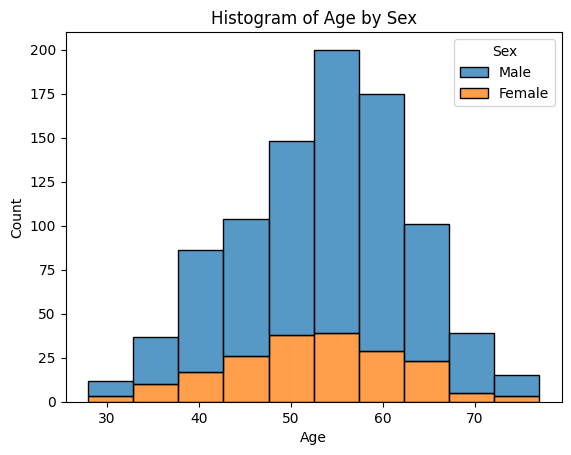

In [ ]:
# Plot histogram of Age by Sex
sns.histplot(data=hd_df, x='Age', hue='Sex', multiple='stack', bins=10)
plt.title('Histogram of Age by Sex')
plt.xlabel('Age')
plt.ylabel('Count')
plt.show()

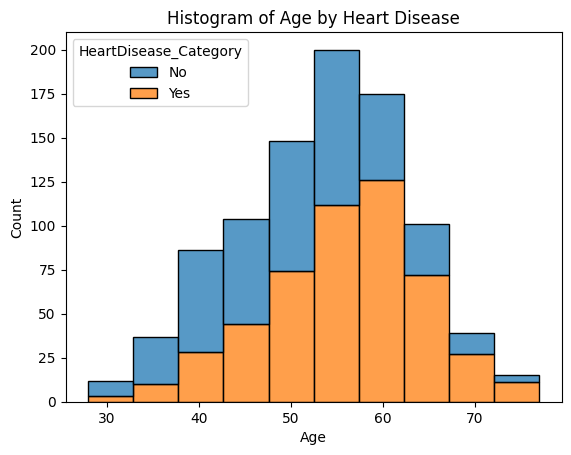

In [ ]:
# Plot histogram of Age by Heart Disease
sns.histplot(data=hd_df, x='Age', hue='HeartDisease_Category', multiple='stack', bins=10)
plt.title('Histogram of Age by Heart Disease')
plt.xlabel('Age')
plt.ylabel('Count')
plt.show()

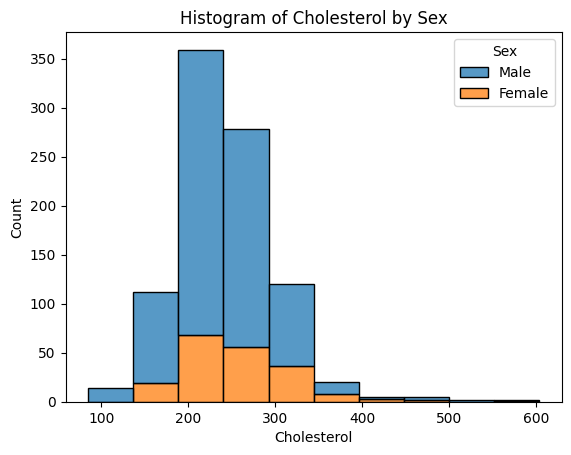

In [ ]:
# Plot histogram of Cholesterol by Sex
sns.histplot(data=hd_df, x='Imputed_Cholesterol', hue='Sex', multiple='stack', bins=10)
plt.title('Histogram of Cholesterol by Sex')
plt.xlabel('Cholesterol')
plt.ylabel('Count')
plt.show()

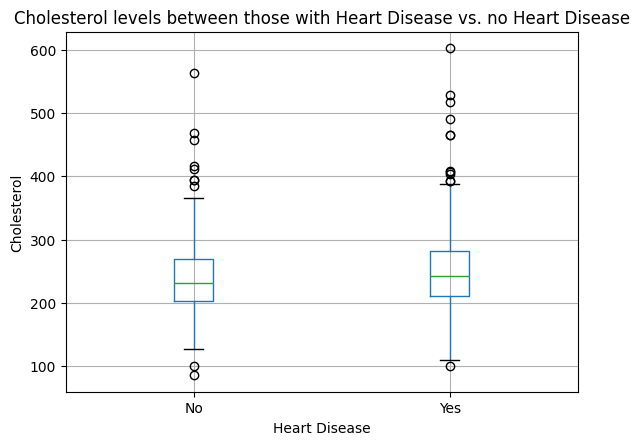

In [ ]:
# Plot Box Plot of cholesterol and heart disease
hd_df.boxplot(column='Imputed_Cholesterol', by='HeartDisease_Category')
plt.title('Cholesterol levels between those with Heart Disease vs. no Heart Disease')
plt.suptitle('')  # Remove default title
plt.xlabel('Heart Disease')
plt.ylabel('Cholesterol')
plt.show()

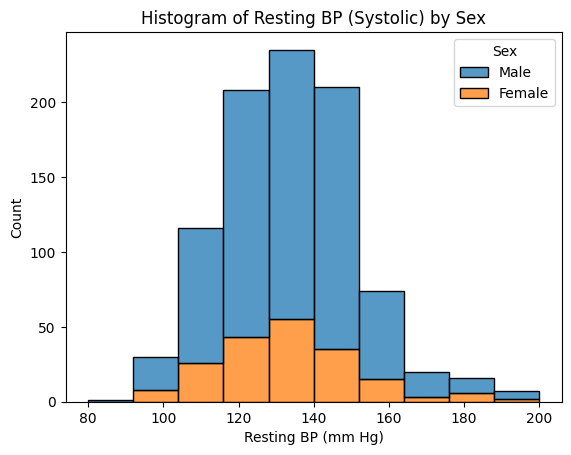

In [ ]:
# Plot histogram of Resting BP by Sex
sns.histplot(data=hd_df, x='RestingBP', hue='Sex', multiple='stack', bins=10)
plt.title('Histogram of Resting BP (Systolic) by Sex')
plt.xlabel('Resting BP (mm Hg)')
plt.ylabel('Count')
plt.show()

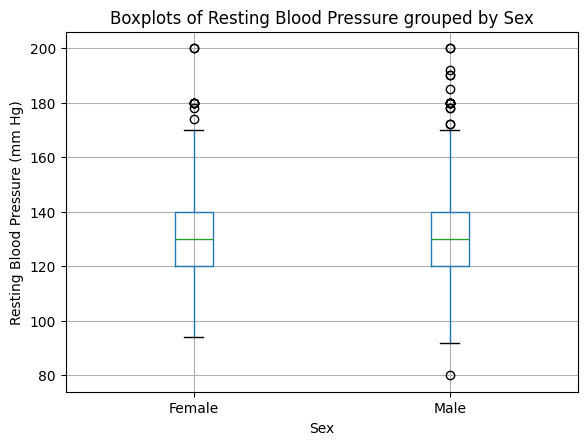

In [ ]:
# Plot Box Plot of Resting BP by Sex
hd_df.boxplot(column='RestingBP', by='Sex')
plt.title('Boxplots of Resting Blood Pressure grouped by Sex')
plt.suptitle('')  # Remove default title
plt.xlabel('Sex')
plt.ylabel('Resting Blood Pressure (mm Hg)')
plt.show()

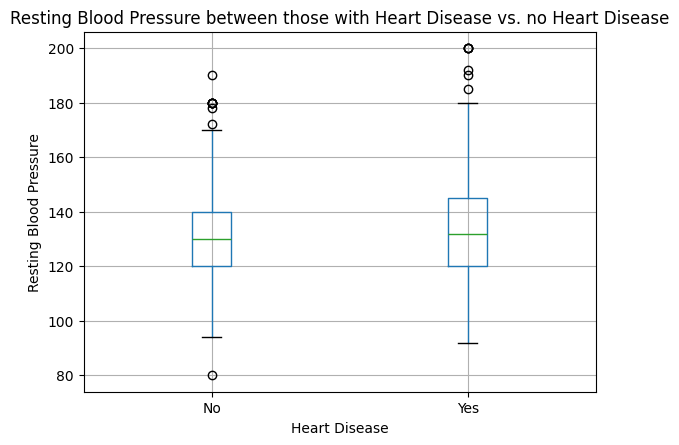

In [ ]:
# Plot Box Plot of resting blood pressure and heart disease
hd_df.boxplot(column='RestingBP', by='HeartDisease_Category')
plt.title('Resting Blood Pressure between those with Heart Disease vs. no Heart Disease')
plt.suptitle('')  # Remove default title
plt.xlabel('Heart Disease')
plt.ylabel('Resting Blood Pressure')
plt.show()

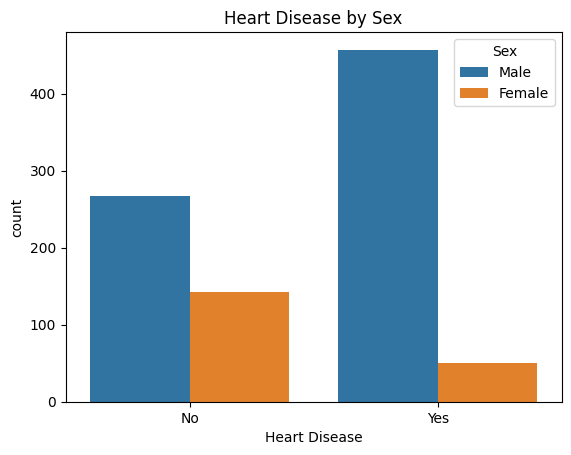

In [ ]:
# Grouped Bar Chart of Heart Disease by Sex
sns.countplot(data=hd_df, x='HeartDisease_Category', hue='Sex')
plt.title("Heart Disease by Sex")
plt.xlabel('Heart Disease')
plt.show()

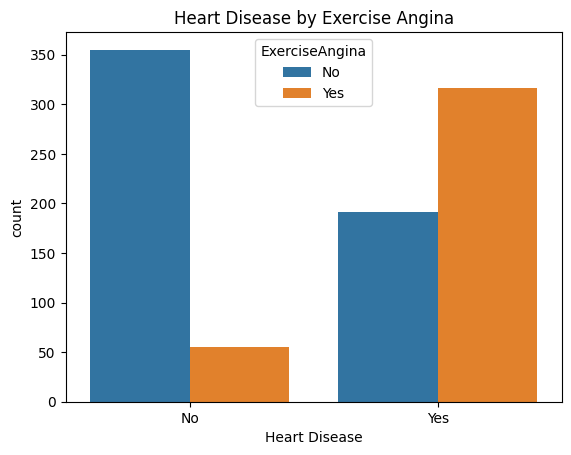

In [ ]:
# Grouped Bar Chart of Heart Disease by Exercise Angina
sns.countplot(data=hd_df, x='HeartDisease_Category', hue='ExerciseAngina')
plt.title("Heart Disease by Exercise Angina")
plt.xlabel('Heart Disease')
plt.show()

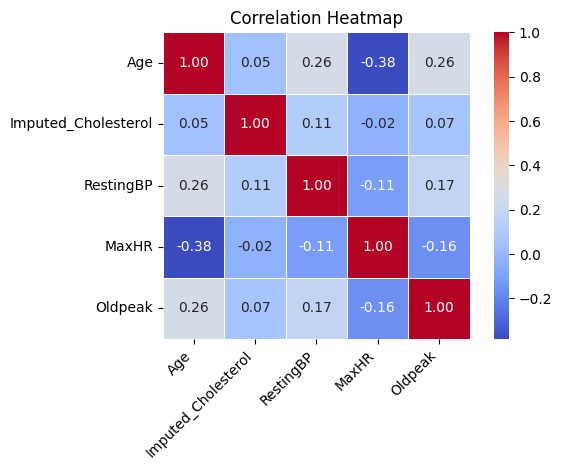

In [ ]:
# Compute correlation matrix for only specific columns
columns_to_correlate = ['Age', 'Imputed_Cholesterol', 'RestingBP', 'MaxHR', 'Oldpeak']
corr_matrix = hd_df[columns_to_correlate].corr()

# Draw the heatmap
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f", square=True, linewidths=.5)
plt.title("Correlation Heatmap")
plt.xticks(rotation=45, ha='right') # 45-degree angle for x-axis labels
plt.tight_layout()  # Adjust layout to prevent label cutoff
plt.show()

In [ ]:
# Helps me remember what the variables are rather than scrolling to the top :-)
print(hd_scaled_df.columns)

Index(['Age', 'RestingBP', 'Imputed_Cholesterol', 'MaxHR', 'Oldpeak', 'Sex',
       'ChestPainType', 'Cholesterol', 'FastingBS', 'RestingECG',
       'ExerciseAngina', 'ST_Slope', 'HeartDisease', 'Sex_Male', 'Ex_Ang_Yes',
       'FastingBS_Yes', 'ChestPainType_ATA', 'ChestPainType_NAP',
       'ChestPainType_TA', 'RestingECG_Normal', 'RestingECG_ST',
       'ST_Slope_Flat', 'ST_Slope_Up', 'HeartDisease_Category'],
      dtype='object')


## Fit logistic regression model using all features

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
# Define features to use in the model
cols_to_use = ['Age', 'RestingBP', 'Imputed_Cholesterol', 'MaxHR', 'Oldpeak', 'Sex_Male', 'Ex_Ang_Yes',
               'FastingBS_Yes', 'ChestPainType_ATA', 'ChestPainType_NAP', 'ChestPainType_TA',
               'RestingECG_Normal', 'RestingECG_ST', 'ST_Slope_Flat', 'ST_Slope_Up']

# Extract target variable (heart disease status)
y = hd_scaled_df['HeartDisease']

# Use feature variables
X = hd_scaled_df[cols_to_use]

# Split data into training (80%) and testing (20%) sets with fixed random state for reproducibility
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=85)

# Train logistic regression model with increased max_iter to ensure convergence
# Code kept crashing with fewer iterations, so set as 10,000
lr_model = LogisticRegression(max_iter=10000).fit(X_train, y_train)

## Determine probabilities and predictions, report results

In [ ]:
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from sklearn.metrics import roc_auc_score

# Import necessary evaluation metrics from scikit-learn

# Predict probabilities and classes
y_prob = lr_model.predict_proba(X_test)[:, 1]  # Get probability estimates for positive class (class 1)
y_pred = lr_model.predict(X_test)  # Get class predictions (0 or 1)

# Evaluate the model using multiple metrics

accuracy = accuracy_score(y_test, y_pred)  # Correct predictions / total predictions
auc = roc_auc_score(y_test, y_prob)  # Calculate model's ability to discriminate
target_names = ['No Heart Disease', 'Heart Disease']
report = classification_report(y_test, y_pred, target_names=target_names)  # Generate detailed classification metrics

# Display evaluation results
print(f"\nAccuracy: {accuracy:.3f}")
print(f"\nAUC: {auc:.3f}")
print("\nClassification Report\n",report)


Accuracy: 0.880

AUC: 0.944

Classification Report
                   precision    recall  f1-score   support

No Heart Disease       0.83      0.88      0.86        74
   Heart Disease       0.92      0.88      0.90       110

        accuracy                           0.88       184
       macro avg       0.87      0.88      0.88       184
    weighted avg       0.88      0.88      0.88       184



## Create confusion matrix with labels to make it stand out

In [ ]:
def display_matrix(y_test,y_pred):
  import matplotlib.pyplot as plt
  import seaborn as sns
  conf_matrix = confusion_matrix(y_test, y_pred)  # Create confusion matrix (TN, FP, FN, TP)

  TrueNegative, FalsePositive, FalseNegative, TruePositive = conf_matrix.ravel()

  labels = np.array([
    [f"True Negative\n{TrueNegative}", f"False Positive\n{FalsePositive}"],
    [f"False Negative\n{FalseNegative}", f"True Positive\n{TruePositive}"]
  ])

  plt.figure(figsize=(5,4))
  sns.heatmap(conf_matrix, annot=labels, fmt='', cmap='Blues', cbar=False,
            xticklabels=['Pred Neg', 'Pred Pos'],
            yticklabels=['Actual Neg', 'Actual Pos'])

  plt.xlabel("Predicted")
  plt.ylabel("Actual")
  plt.title("Confusion Matrix")

  plt.show()

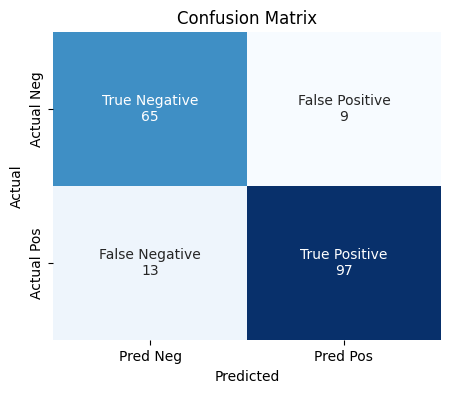

In [ ]:
display_matrix(y_test,y_pred)

## Determine statistically significant features and evaluate which to remove from the model

In [ ]:
import statsmodels.api as sm

# Add a constant term to the training and test features
X_train_sm = sm.add_constant(X_train)
X_test_sm = sm.add_constant(X_test)

# Initialize a logistic regression model using statsmodels
sm_model = sm.Logit(y_train, X_train_sm)

# Fit the model using Newton's method
sm_result = sm_model.fit(method ='newton')

# Display results
print(sm_result.summary())

# Create a DataFrame of p-values to test for significance
p_values = pd.DataFrame(sm_result.pvalues, columns=['p_value'], index=X_train_sm.columns)

# Flag variables as significant if p-value within 95% confidence level
p_values['significant'] = p_values['p_value'] < 0.05
print("\nP-values and Significance:\n", p_values)

# Display statistically significant variables
significant_vars = p_values[p_values['significant']].index.tolist()
print("\nStatistically Significant Variables (p < 0.05):\n", significant_vars)

Optimization terminated successfully.
         Current function value: 0.341094
         Iterations 7
                           Logit Regression Results                           
Dep. Variable:           HeartDisease   No. Observations:                  733
Model:                          Logit   Df Residuals:                      717
Method:                           MLE   Df Model:                           15
Date:                Mon, 06 Apr 2026   Pseudo R-squ.:                  0.5054
Time:                        23:40:01   Log-Likelihood:                -250.02
converged:                       True   LL-Null:                       -505.54
Covariance Type:            nonrobust   LLR p-value:                 2.625e-99
                          coef    std err          z      P>|z|      [0.025      0.975]
---------------------------------------------------------------------------------------
const                  -1.3483      0.575     -2.346      0.019      -2.475      -0.222
Ag

## Show important features

In [ ]:
feature_importance = pd.Series(abs(lr_model.coef_[0]), index=X.columns).sort_values(ascending=False)
print(feature_importance.sort_values(ascending=False))

Sex_Male               1.543913
ChestPainType_ATA      1.483619
ChestPainType_NAP      1.318562
ST_Slope_Flat          1.294077
ChestPainType_TA       1.037720
Ex_Ang_Yes             0.955868
FastingBS_Yes          0.946949
ST_Slope_Up            0.784420
Oldpeak                0.458091
MaxHR                  0.259943
Age                    0.110655
RestingECG_Normal      0.081229
Imputed_Cholesterol    0.080757
RestingBP              0.047455
RestingECG_ST          0.043808
dtype: float64


## Determine optimal threshold using Youden’s J Statistic

In [ ]:
from sklearn.metrics import roc_curve

# Calculate false positive rate, true positive rate, and thresholds
# y_test contains the actual labels, y_prob contains the predicted probabilities
FalsePositiveRate, TruePositiveRate, thresholds = roc_curve(y_test, y_prob)

# Determining the maximum difference between true positive rate and false positive rate
optimal_idx = np.argmax(TruePositiveRate - FalsePositiveRate)

# Get the threshold value corresponding to the optimal index
optimal_threshold = thresholds[optimal_idx]

print(f"Optimal Threshold: {optimal_threshold: .3f}")

Optimal Threshold:  0.340


## Display new results after optimizing threshold


Accuracy:  0.902

Classification Report (Optimized Threshold):
               precision    recall  f1-score   support

           0       0.91      0.84      0.87        74
           1       0.90      0.95      0.92       110

    accuracy                           0.90       184
   macro avg       0.90      0.89      0.90       184
weighted avg       0.90      0.90      0.90       184


Confusion Matrix (Optimized Threshold):



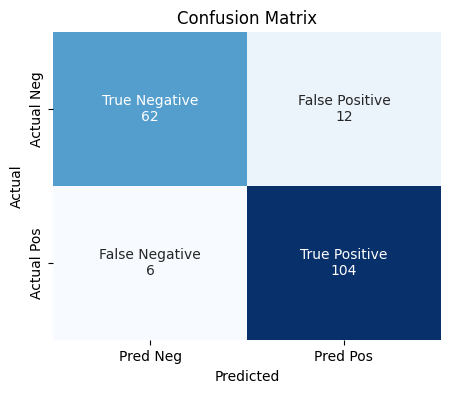

In [ ]:
# Get predicted values for those that are above the threshold
y_pred = (y_prob >= optimal_threshold).astype(int)

# Obtain new results using the reduced threshold predictions
report = classification_report(y_test, y_pred)
accuracy = accuracy_score(y_test, y_pred)

print(f"\nAccuracy: {accuracy: .3f}")
print("\nClassification Report (Optimized Threshold):\n", report)
print("\nConfusion Matrix (Optimized Threshold):\n")
display_matrix(y_test,y_pred)

## Fit reduced model

In [ ]:
# Remove some features. After several variations,
# I kept Age and MaxHR in the model as the model performed best with them included
reduced_cols_to_include =  ['Age', 'MaxHR', 'Oldpeak', 'Sex_Male', 'Ex_Ang_Yes', 'FastingBS_Yes', 'ChestPainType_ATA',
                        'ChestPainType_NAP', 'ChestPainType_TA', 'ST_Slope_Flat']

# Set up and train model on reduced set of features
reduced_X = hd_scaled_df[reduced_cols_to_include]
reduced_y = hd_scaled_df['HeartDisease']

reduced_X_train, reduced_X_test, reduced_y_train, reduced_y_test = train_test_split(reduced_X, reduced_y, test_size=0.2, random_state=85)

reduced_lr_model = LogisticRegression(max_iter=10000).fit(reduced_X_train, reduced_y_train)


## Display new results on reduced model, default threshold


Accuracy: 0.880

AUC: 0.939

Classification Report
               precision    recall  f1-score   support

           0       0.83      0.88      0.86        74
           1       0.92      0.88      0.90       110

    accuracy                           0.88       184
   macro avg       0.87      0.88      0.88       184
weighted avg       0.88      0.88      0.88       184

Confusion Matrix:



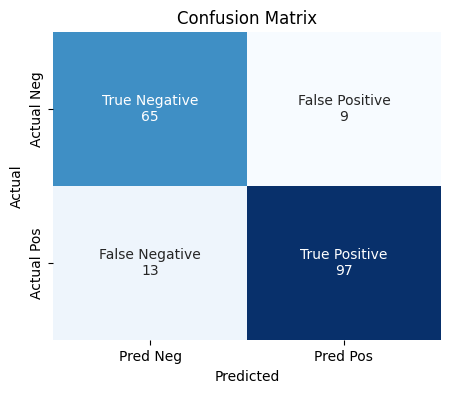

In [ ]:
# Obtain the probabilities and predictions based on the reduced model
y_probs_lr = reduced_lr_model.predict_proba(reduced_X_test)[:, 1]
y_pred_lr = reduced_lr_model.predict(reduced_X_test)

# Evaluate the reduced model
report = classification_report(reduced_y_test, y_pred_lr)
accuracy = accuracy_score(reduced_y_test, y_pred_lr)
auc = roc_auc_score(reduced_y_test, y_probs_lr)

# Print results
print(f"\nAccuracy: {accuracy:.3f}")
print(f"\nAUC: {auc:.3f}")
print("\nClassification Report\n",report)
print("Confusion Matrix:\n")
display_matrix(reduced_y_test,y_pred_lr)

## Calculate new optimum threshold and display results on reduced model

New optimal Threshold:  0.230

Accuracy:  0.902

AUC: 0.939

Classification Report (Optimized Threshold):
               precision    recall  f1-score   support

           0       0.95      0.80      0.87        74
           1       0.88      0.97      0.92       110

    accuracy                           0.90       184
   macro avg       0.91      0.89      0.90       184
weighted avg       0.91      0.90      0.90       184


Confusion Matrix (Optimized Threshold):



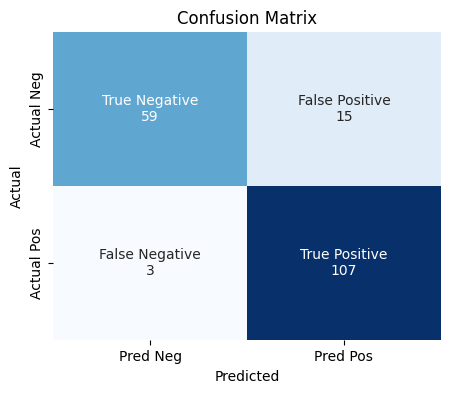

In [ ]:
# As before, calculate the optimum threshold on the reduced model predictions
FalsePositiveRate, TruePositiveRate, thresholds = roc_curve(reduced_y_test, y_probs_lr)
optimal_idx = np.argmax(TruePositiveRate - FalsePositiveRate)
optimal_threshold = thresholds[optimal_idx]
print(f"New optimal Threshold: {optimal_threshold: .3f}")

# Evaluate the reduced model based on the optimum threshold
y_pred_lr = (y_probs_lr >= optimal_threshold).astype(int)
report = classification_report(reduced_y_test, y_pred_lr)
accuracy = accuracy_score(reduced_y_test, y_pred_lr)
auc = roc_auc_score(reduced_y_test, y_probs_lr)

# Print results
print(f"\nAccuracy: {accuracy: .3f}")
print(f"\nAUC: {auc:.3f}")
print("\nClassification Report (Optimized Threshold):\n", report)
print("\nConfusion Matrix (Optimized Threshold):\n")
display_matrix(reduced_y_test,y_pred_lr)

## Create and evaluate SVM model


Accuracy:  0.886

AUC Score:  0.945

Classification Report:
               precision    recall  f1-score   support

           0       0.84      0.89      0.86        74
           1       0.92      0.88      0.90       110

    accuracy                           0.89       184
   macro avg       0.88      0.89      0.88       184
weighted avg       0.89      0.89      0.89       184

Confusion Matrix:



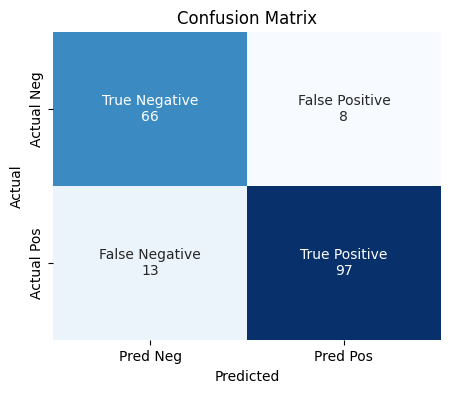

In [ ]:
from sklearn import datasets
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC

#Train the SVM model
svm_model = SVC(kernel='rbf', probability=True, random_state=11)  # use `probability=True` for AUC
svm_model.fit(X_train, y_train)

# Predictions
y_probs_svm = svm_model.predict_proba(X_test)[:, 1]  # Probabilities for AUC
y_pred_svm = svm_model.predict(X_test)

# Evaluate and print results
report = classification_report(y_test, y_pred_svm)
accuracy = accuracy_score(y_test, y_pred_svm)
auc_score = roc_auc_score(y_test, y_probs_svm)

# Print results
print(f"\nAccuracy: {accuracy: .3f}")
print(f"\nAUC Score: {auc_score: .3f}")
print("\nClassification Report:\n", report)
print("Confusion Matrix:\n")
display_matrix(y_test, y_pred_svm)

## Fit a reduced SVM model and evaluate


Accuracy:  0.853

AUC Score:  0.946

Classification Report:
               precision    recall  f1-score   support

           0       0.80      0.85      0.82        74
           1       0.90      0.85      0.87       110

    accuracy                           0.85       184
   macro avg       0.85      0.85      0.85       184
weighted avg       0.86      0.85      0.85       184

Confusion Matrix:



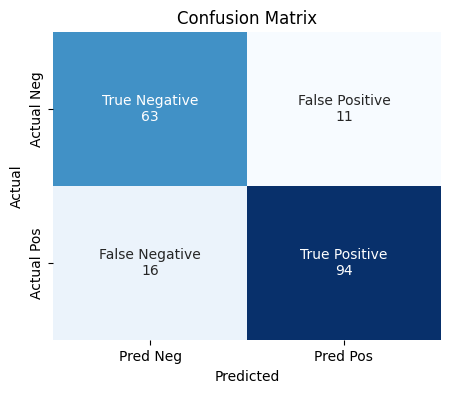

In [ ]:
#The split will use "reduced_X" and "reduced_y" as was done for the reduced Logistic Regression model

#Train the SVM model
svm_reduced_model = SVC(kernel='rbf', probability=True, random_state=2)  # use `probability=True` for AUC
svm_reduced_model.fit(reduced_X_train, reduced_y_train)

# Predictions
y_probs_svm = svm_reduced_model.predict_proba(reduced_X_test)[:, 1]  # Probabilities for AUC
y_pred_svm = svm_reduced_model.predict(reduced_X_test)

# Evaluate and print results
report = classification_report(reduced_y_test, y_pred_svm)
accuracy = accuracy_score(reduced_y_test, y_pred_svm)
auc_score = roc_auc_score(reduced_y_test, y_probs_svm)

# Print results
print(f"\nAccuracy: {accuracy: .3f}")
print(f"\nAUC Score: {auc_score: .3f}")
print("\nClassification Report:\n", report)
print("Confusion Matrix:\n")
display_matrix(reduced_y_test,y_pred_svm)

## Calculating and using the optimum threshold for a reduced SVM model

New optimal Threshold:  0.219

Accuracy:  0.902

AUC Score:  0.946

Classification Report (Optimized Threshold):
               precision    recall  f1-score   support

           0       0.94      0.81      0.87        74
           1       0.88      0.96      0.92       110

    accuracy                           0.90       184
   macro avg       0.91      0.89      0.90       184
weighted avg       0.91      0.90      0.90       184


Confusion Matrix (Optimized Threshold):



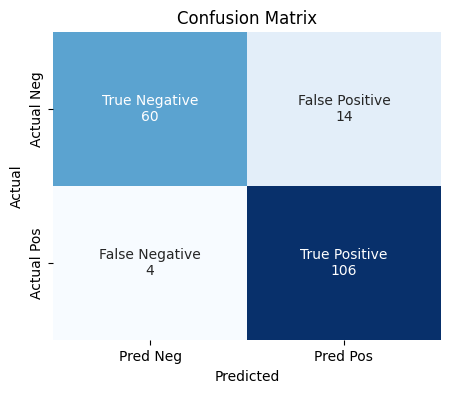

In [ ]:
# As before, calculate the optimum threshold on the reduced model predictions
FalsePositiveRate, TruePositiveRate, thresholds = roc_curve(reduced_y_test, y_probs_svm)
optimal_idx_svm = np.argmax(TruePositiveRate - FalsePositiveRate)
optimal_threshold_svm = thresholds[optimal_idx_svm]
print(f"New optimal Threshold: {optimal_threshold_svm: .3f}")

# Evaluate the reduced model based on the optimum threshold
y_pred_svm = (y_probs_svm >= optimal_threshold_svm).astype(int)
report = classification_report(reduced_y_test, y_pred_svm)
accuracy = accuracy_score(reduced_y_test, y_pred_svm)
auc = roc_auc_score(reduced_y_test, y_probs_svm)

# Print results
print(f"\nAccuracy: {accuracy: .3f}")
print(f"\nAUC Score: {auc: .3f}")
print("\nClassification Report (Optimized Threshold):\n", report)
print("\nConfusion Matrix (Optimized Threshold):\n")
display_matrix(reduced_y_test,y_pred_svm)

## Neural Networks

In [ ]:
#!pip install tensorflow

In [ ]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Input

#### NOTE
X_train, X_test, y_train, y_test were already created when we fit the Logtistic Regression model

## Create and complile the Keras model

In [ ]:
nn_model = Sequential([
    Input(shape=(X_train.shape[1],)),
    Dense(16, activation='relu'),
    Dense(8, activation='relu'),
    Dense(1, activation='sigmoid')
])

nn_model.compile(optimizer='adam', loss='binary_crossentropy',
                 metrics=['accuracy', 'Precision', 'Recall', 'AUC'])
nn_model.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_6 (Dense)                 │ (None, 16)             │           256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 8)              │           136 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 1)              │             9 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 401 (1.57 KB)

 Trainable params: 401 (1.57 KB)

 Non-trainable params: 0 (0.00 B)

## Train and evaluate the Keras model

In [ ]:
# Train the model
history = nn_model.fit(X_train, y_train, epochs=50, batch_size=16, validation_split=0.1, verbose=0)

# Evaluate the model
loss, accuracy, Precision, Recall, AUC = nn_model.evaluate(X_test, y_test)

# Print results of evaluation
print(f'Test Accuracy: {accuracy:.3f}')
print(f'Test AUC: {AUC:.3f}')
print(f'Test Precision: {Precision:.3f}')
print(f'Test Recall: {Recall:.3f}')

6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - AUC: 0.9412 - Precision: 0.9143 - Recall: 0.8727 - accuracy: 0.8750 - loss: 0.3041 
Test Accuracy: 0.875
Test AUC: 0.941
Test Precision: 0.914
Test Recall: 0.873


## To compare with Logistic Regression and SVM, determine Recall for both classes of Heart Disease

6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step 
Precision for No Heart Disease: 0.823
Precision for Heart Disease: 0.914

Recall for No Heart Disease: 0.878
Recall for Heart Disease: 0.873



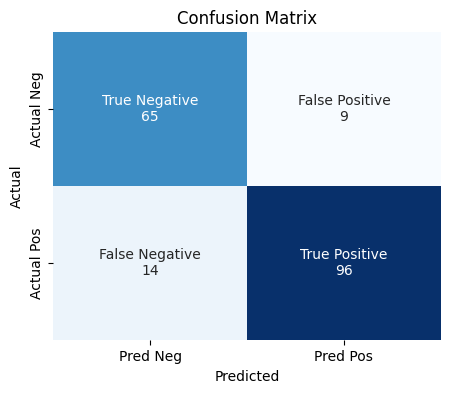

In [ ]:
from sklearn.metrics import recall_score, precision_score

# Generate probability predictions from the keras network model
y_probs_nn = nn_model.predict(X_test)

# Convert probabilities to binary predictions (0 or 1) using a default threshold of 0.5
y_pred_nn = (y_probs_nn > 0.5).astype(int)

# Calculate recall for class 0 (specificity)
recall_class_0 = recall_score(y_test, y_pred_nn, pos_label=0)
# Calculate recall for class 1 (sensitivity)
recall_class_1 = recall_score(y_test, y_pred_nn, pos_label=1)

# Calculate precision for class 0 (specificity)
precision_class_0 = precision_score(y_test, y_pred_nn, pos_label=0)
# Calculate precision for class 1 (sensitivity)
precision_class_1 = precision_score(y_test, y_pred_nn, pos_label=1)

# Print the scores
print(f"Precision for No Heart Disease: {precision_class_0:.3f}")
print(f"Precision for Heart Disease: {precision_class_1:.3f}\n")

print(f"Recall for No Heart Disease: {recall_class_0:.3f}")
print(f"Recall for Heart Disease: {recall_class_1:.3f}\n")

display_matrix(y_test,y_pred_nn)

## Determine optimal threshold as was done for Logistic Regression and SVM

In [ ]:
# Determine optimum threshold
FalsePositiveRate, TruePositiveRate, thresholds = roc_curve(y_test, y_pred_nn)
optimal_idx = np.argmax(TruePositiveRate - FalsePositiveRate)
keras_optimal_threshold = thresholds[optimal_idx]

# Print results
print(f"Keras optimal threshold: {keras_optimal_threshold: .3f}")


Keras optimal threshold:  1.000


## Use optimal threshold

Precision for No Heart Disease: 0.912
Precision for Heart Disease: 0.897

Recall for No Heart Disease: 0.838
Recall for Heart Disease: 0.945



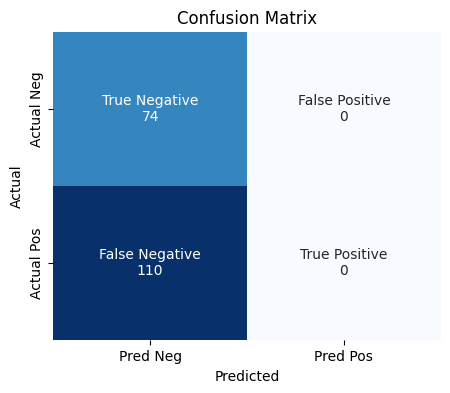

In [ ]:
# Using optimal threshold
y_pred_nn = (y_probs_nn > keras_optimal_threshold).astype(int)

# Calculate recall for class 0 (specificity)
recall_class_0 = recall_score(y_test, y_pred, pos_label=0)
# Calculate recall for class 1 (sensitivity)
recall_class_1 = recall_score(y_test, y_pred, pos_label=1)

# Calculate precision for class 0 (specificity)
precision_class_0 = precision_score(y_test, y_pred, pos_label=0)
# Calculate precision for class 1 (sensitivity)
precision_class_1 = precision_score(y_test, y_pred, pos_label=1)

# Print the scores
print(f"Precision for No Heart Disease: {precision_class_0:.3f}")
print(f"Precision for Heart Disease: {precision_class_1:.3f}\n")

# Print the recall scores
print(f"Recall for No Heart Disease: {recall_class_0:.3f}")
print(f"Recall for Heart Disease: {recall_class_1:.3f}\n")

display_matrix(y_test,y_pred_nn)

## Create reduced Keras model with optimal threshold

#### NOTE
reduced_X_train, reduced_X_test, reduced_y_train, new_ y_test were already created when we fit the Logtistic Regression model with a reduced number of features

In [ ]:
nn_red_model = Sequential([
    Input(shape=(reduced_X_train.shape[1],)),
    Dense(16, activation='relu'),
    Dense(8, activation='relu'),
    Dense(1, activation='sigmoid')
])

nn_red_model.compile(optimizer='adam', loss='binary_crossentropy',
                 metrics=['accuracy', 'Precision', 'Recall', 'AUC'])

red_history = nn_red_model.fit(reduced_X_train, reduced_y_train, epochs=50, batch_size=16, validation_split=0.1, verbose=0)

# Evaluate the model
loss, accuracy, Precision, Recall, AUC = nn_red_model.evaluate(reduced_X_test, reduced_y_test)

# Print results of evaluation
print(f'Test Accuracy: {accuracy:.3f}')
print(f'Test AUC: {AUC:.3f}')
print(f'Test Precision: {Precision:.3f}')
print(f'Test Recall: {Recall:.3f}')


6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - AUC: 0.9378 - Precision: 0.9192 - Recall: 0.8273 - accuracy: 0.8533 - loss: 0.3281 
Test Accuracy: 0.853
Test AUC: 0.938
Test Precision: 0.919
Test Recall: 0.827


## Determine optimal threshold

In [ ]:
# Generate probability predictions from the keras network model
y_probs_nn = nn_red_model.predict(reduced_X_test)

# Determine new optimum threshold
FalsePositiveRate, TruePositiveRate, thresholds = roc_curve(reduced_y_test, y_probs_nn)
optimal_idx = np.argmax(TruePositiveRate - FalsePositiveRate)
keras_optimal_threshold = thresholds[optimal_idx]

# Print results
print(f"Keras optimal threshold: {keras_optimal_threshold: .3f}")

6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step
Keras optimal threshold:  0.274


## Use optimum threshold

Precision for No Heart Disease: 0.882
Precision for Heart Disease: 0.879

Recall for No Heart Disease: 0.811
Recall for Heart Disease: 0.927



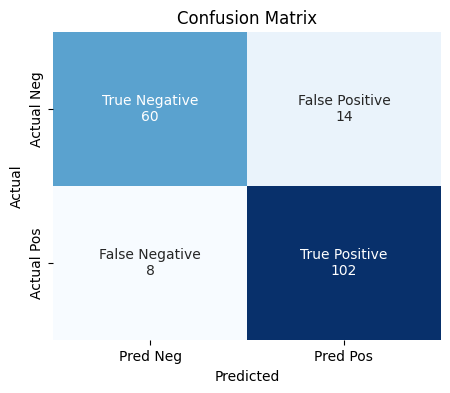

In [ ]:
# Using optimal threshold
y_pred_nn = (y_probs_nn > keras_optimal_threshold).astype(int)

# Calculate recall for class 0 (specificity)
recall_class_0 = recall_score(reduced_y_test, y_pred_nn, pos_label=0)
# Calculate recall for class 1 (sensitivity)
recall_class_1 = recall_score(reduced_y_test, y_pred_nn, pos_label=1)

# Calculate precision for class 0 (specificity)
precision_class_0 = precision_score(reduced_y_test, y_pred_nn, pos_label=0)
# Calculate precision for class 1 (sensitivity)
precision_class_1 = precision_score(reduced_y_test, y_pred_nn, pos_label=1)

# Print the scores
print(f"Precision for No Heart Disease: {precision_class_0:.3f}")
print(f"Precision for Heart Disease: {precision_class_1:.3f}\n")

print(f"Recall for No Heart Disease: {recall_class_0:.3f}")
print(f"Recall for Heart Disease: {recall_class_1:.3f}\n")

display_matrix(reduced_y_test,y_pred_nn)

## Return the best threshold based on the ROC curve

In [ ]:
def find_best_threshold(y_true, y_prob):
    FalsePositiveRate, TruePositiveRate, thresholds = roc_curve(y_true, y_prob)
    j_scores = TruePositiveRate - FalsePositiveRate
    best_idx = np.argmax(j_scores)
    return thresholds[best_idx]

## Now show results side-by-side

In [ ]:
results = []

models = {
    "Logistic Regression": (reduced_y_test, y_pred_lr, y_probs_lr),
    "SVM": (reduced_y_test, y_pred_svm, y_probs_svm),
    "Keras NN": (reduced_y_test, y_pred_nn, y_probs_nn)
}

for name, (y_model_test, preds, probs) in models.items():
    auc = roc_auc_score(y_model_test, probs)
    best_thresh = find_best_threshold(y_model_test, probs)

    results.append({
        "Model": name,
        "Accuracy": accuracy_score(y_model_test, preds),
        "Precision": precision_score(y_model_test, preds),
        "Recall": recall_score(y_model_test, preds),
        "F1 Score": f1_score(y_model_test, preds),
        "AUC": auc,
        "Optimal Threshold": best_thresh
    })

results_df = pd.DataFrame(results)
print(results_df)

                 Model  Accuracy  Precision    Recall  F1 Score       AUC  \
0  Logistic Regression  0.902174   0.877049  0.972727  0.922414  0.938575   
1                  SVM  0.902174   0.883333  0.963636  0.921739  0.946314   
2             Keras NN  0.880435   0.879310  0.927273  0.902655  0.937592   

   Optimal Threshold  
0           0.229894  
1           0.218775  
2           0.274360  


# Show confusion matrices side-by-side

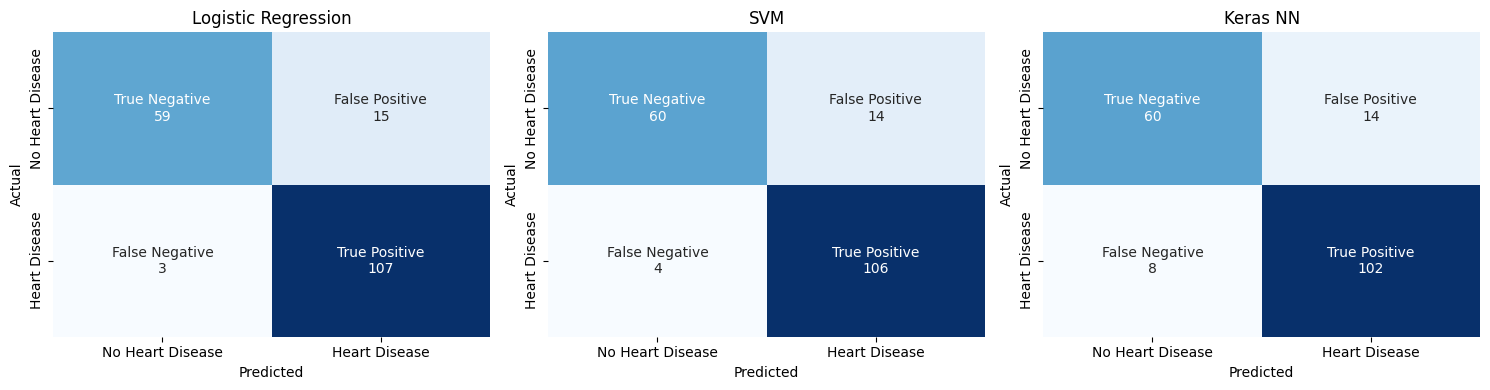

In [ ]:
# Create subplot layout
fig, axes = plt.subplots(1, len(models), figsize=(15, 4))

# Loop through models
for ax, (name, (y_test_model, preds, probs)) in zip(axes, models.items()):

    cm = confusion_matrix(y_test_model, preds)
    TrueNegative, FalsePositive, FalseNegative, TruePositive = cm.ravel()

    # Custom labels inside each cell
    labels = np.array([
        [f"True Negative\n{TrueNegative}", f"False Positive\n{FalsePositive}"],
        [f"False Negative\n{FalseNegative}", f"True Positive\n{TruePositive}"]
    ])

    sns.heatmap(
        cm,
        annot=labels,
        fmt='',
        cmap='Blues',
        cbar=False,
        ax=ax,
        xticklabels=["No Heart Disease", "Heart Disease"],
        yticklabels=["No Heart Disease", "Heart Disease"]
    )

    ax.set_title(name)
    ax.set_xlabel("Predicted")
    ax.set_ylabel("Actual")

# Adjust layout
plt.tight_layout()
plt.show()

## Show AUC side-by-side

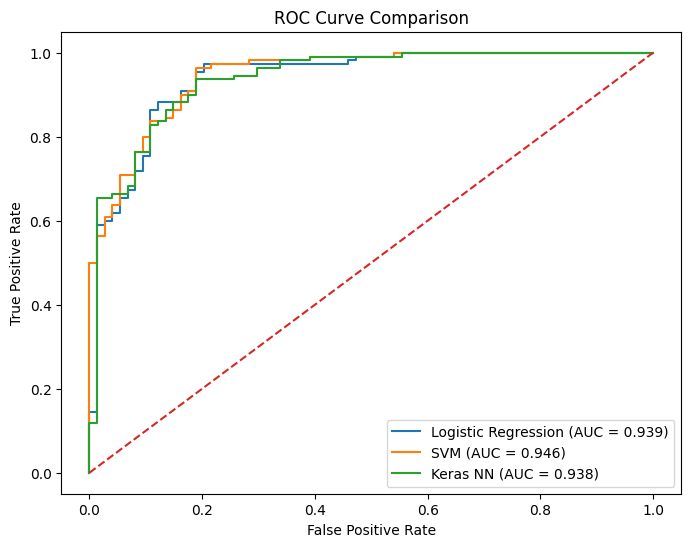

In [ ]:
# Store model data
roc_models = {
    "Logistic Regression": (reduced_y_test, y_probs_lr),
    "SVM": (reduced_y_test, y_probs_svm),
    "Keras NN": (reduced_y_test, y_probs_nn)
}

plt.figure(figsize=(8, 6))

for name, (y_model_test, y_prob) in roc_models.items():
    FalsePositiveRate, TruePositiveRate, _ = roc_curve(y_model_test, y_prob)
    auc_score = roc_auc_score(y_model_test, y_prob)
    plt.plot(FalsePositiveRate, TruePositiveRate, label=f"{name} (AUC = {auc_score:.3f})")

# Diagonal reference line
plt.plot([0, 1], [0, 1], linestyle="--")

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve Comparison")
plt.legend(loc="lower right")
plt.show()